# 3.1

Shape of observations: (15,)
Initial test - r(q0, q0) = 1.000000

Running Metropolis algorithm for 10000 iterations...
Proposal distribution: N(q_prev, D) with D = diag([0.01, 2e-10])
Running Metropolis-Hastings MCMC...
  Completed 200/10000 iterations, acceptance rate: 0.729
  Completed 400/10000 iterations, acceptance rate: 0.772
  Completed 600/10000 iterations, acceptance rate: 0.798
  Completed 800/10000 iterations, acceptance rate: 0.814
  Completed 1000/10000 iterations, acceptance rate: 0.818
  Completed 1200/10000 iterations, acceptance rate: 0.826
  Completed 1400/10000 iterations, acceptance rate: 0.832
  Completed 1600/10000 iterations, acceptance rate: 0.836
  Completed 1800/10000 iterations, acceptance rate: 0.840
  Completed 2000/10000 iterations, acceptance rate: 0.835
  Completed 2200/10000 iterations, acceptance rate: 0.834
  Completed 2400/10000 iterations, acceptance rate: 0.835
  Completed 2600/10000 iterations, acceptance rate: 0.838
  Completed 2800/10000 iterati

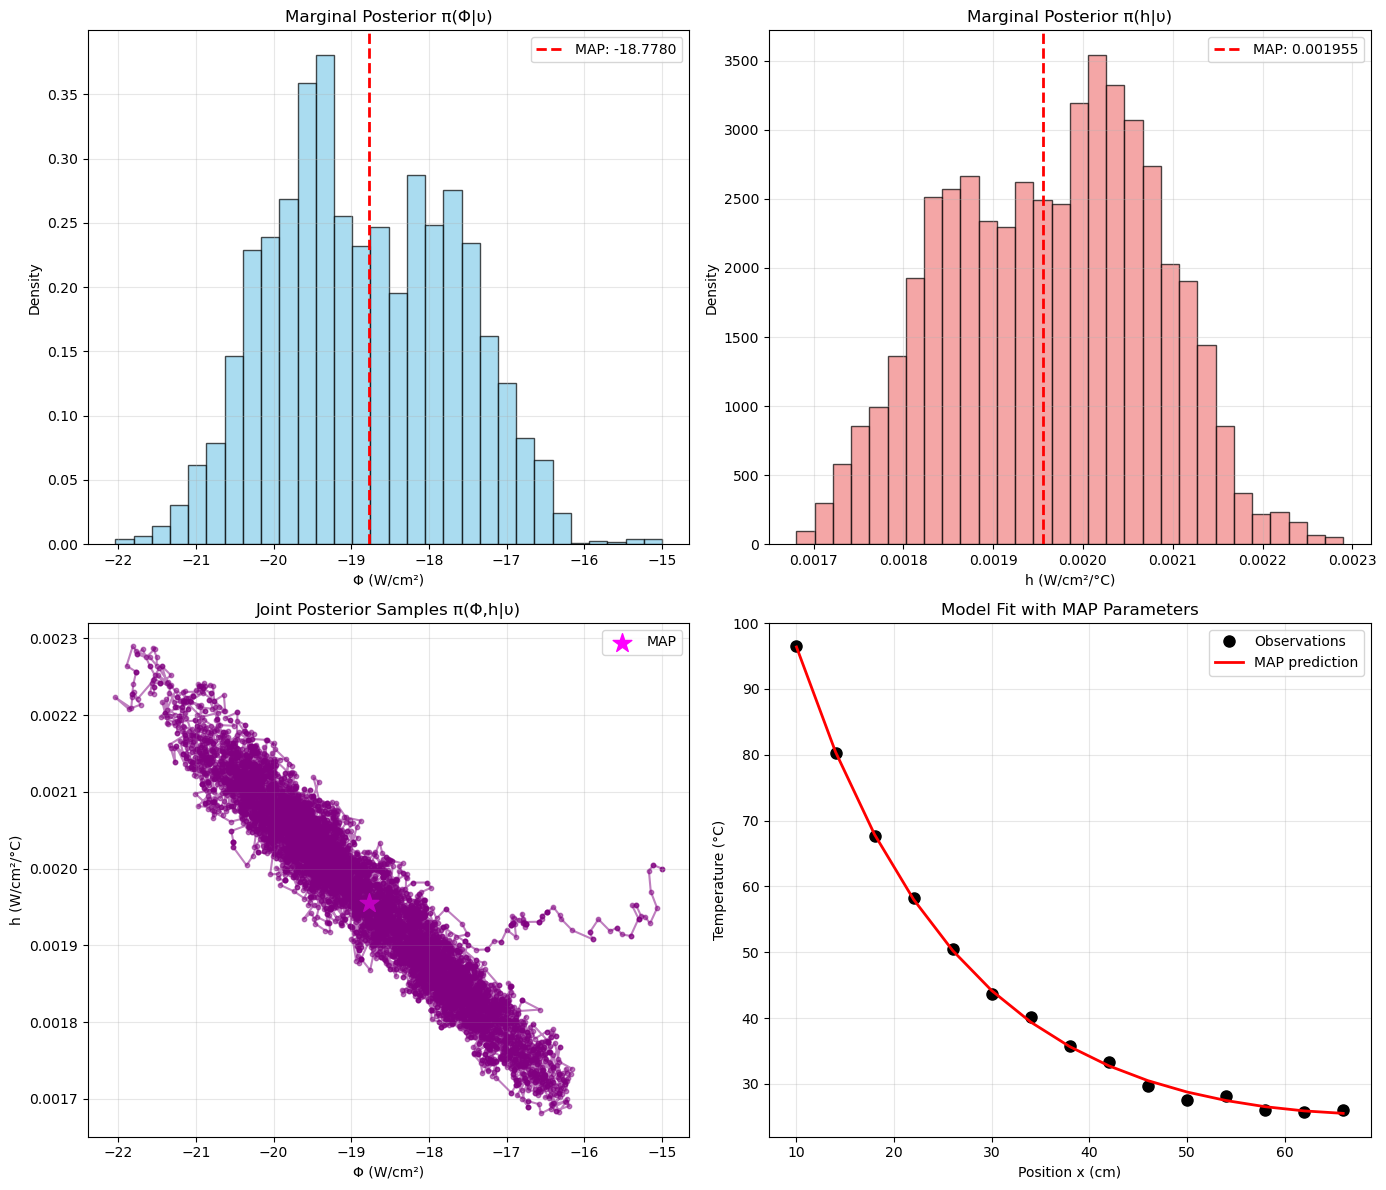


Results saved to 'problem3.1_results.npz'


In [2]:
import os, sys, numpy as np, matplotlib.pyplot as plt
sys.path.append('../hw1')
import heat_rod as hr
from mcmc import *
from scipy.io import loadmat

data_name ="HW06_Problem3.mat"
samples, q_map, posterior_values, acceptance_rate = run_metropolis_for_heat_equation(data_name = data_name, M = 10000)

# Save results
np.savez('problem3.1_results.npz',
            samples=samples,
            q_map=q_map,
            posterior_values=posterior_values,
            acceptance_rate=acceptance_rate)

print(f"\nResults saved to 'problem3.1_results.npz'")

###
$q_{MAP} =  [-18.72 W/cm²;
  h = 0.00195 W/cm²/°C]$ after removing 300 burn-in samples.

In [3]:
burnin = 300
q_map_after_burnin = samples[np.argmax(posterior_values[burnin:])]
print(f"MAP point after removing {burnin} burn-in points", q_map_after_burnin)
print(f"MAP point wihout removing {burnin} burn-in points", q_map)

MAP point after removing 300 burn-in points [-1.87244917e+01  1.95073235e-03]
MAP point wihout removing 300 burn-in points [-1.87780074e+01  1.95508105e-03]


##
Histograms of Samples



KDE of PDF

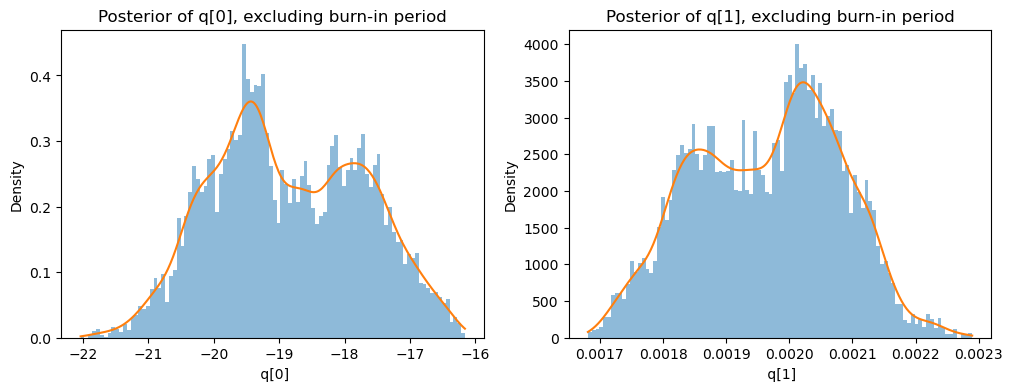

In [5]:
from scipy.stats import gaussian_kde
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    s = samples[burnin:, i] ####TODO: BURNIN INCLUDED?
    
    # Histogram
    axes[i].hist(s, bins=100, density=True, alpha=0.5)
    
    # KDE smooth curve
    kde = gaussian_kde(s)
    x = np.linspace(min(s), max(s), 300)
    axes[i].plot(x, kde(x))
    
    axes[i].set_title(f"Posterior of q[{i}], excluding burn-in period")
    axes[i].set_xlabel(f" q[{i}]")
    axes[i].set_ylabel("Density")

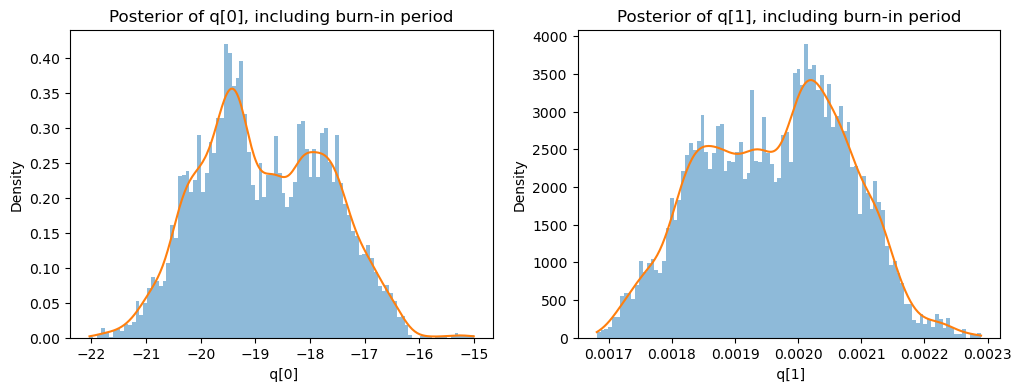

In [6]:
from scipy.stats import gaussian_kde
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    s = samples[:, i] ####TODO: BURNIN INCLUDED?
    
    # Histogram
    axes[i].hist(s, bins=100, density=True, alpha=0.5)
    
    # KDE smooth curve
    kde = gaussian_kde(s)
    x = np.linspace(min(s), max(s), 300)
    axes[i].plot(x, kde(x))
    
    axes[i].set_title(f"Posterior of q[{i}], including burn-in period")
    axes[i].set_xlabel(f" q[{i}]")
    axes[i].set_ylabel("Density")

Note: q[0] is $\phi$, while q[1] is $h$.